# Visualización de Almacenes

Carga los ficheros `warehouse_mapXX.json` y genera para cada almacén:
- Tabla resumen con dimensiones, número de estanterías y zonas
- Imagen vista cenital con estanterías, goals, WAITING y DROPOFF

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow
import pandas as pd
import numpy as np

MAP_DIR = Path('../simulacion/controllers/rl_train_STHWP')
OUT_DIR = Path('imagenes')
OUT_DIR.mkdir(exist_ok=True)

WAREHOUSE_IDS = [1, 2, 3, 4, 5]

def load_map(wh_id):
    p = MAP_DIR / f'warehouse_map{wh_id:02d}.json'
    with open(p) as f:
        return json.load(f)

maps = {i: load_map(i) for i in WAREHOUSE_IDS}
print('Mapas cargados:', list(maps.keys()))

Mapas cargados: [1, 2, 3, 4, 5]


## Tabla resumen

In [2]:
rows = []
for wh_id, d in maps.items():
    m = d['map']
    res = m['resolution']
    W = m['width']  * res
    L = m['height'] * res
    shelves = d['shelves']
    zones   = d['zones']
    waiting = zones['waiting']
    dropoff = zones['dropoff']
    rows.append({
        'Almacén': f'WH{wh_id:02d}',
        'Ancho (m)': W,
        'Largo (m)': L,
        'Área (m²)': W * L,
        'Nº estanterías': len(shelves),
        'Nº goals': len(shelves),
        'Origen X': m['origin'][0],
        'Origen Y': m['origin'][1],
        'WAITING': f"({waiting['x']}, {waiting['y']})",
        'DROPOFF': f"({dropoff['x']}, {dropoff['y']})",
    })

df = pd.DataFrame(rows).set_index('Almacén')
df

,Ancho (m),Largo (m),Área (m²),Nº estanterías,Nº goals,Origen X,Origen Y,WAITING,DROPOFF
Almacén,,,,,,,,,
WH01,23.00,22.0,506.0,28,28,-13.0,-10.0,"(-6.6, -8.5)","(-11.0, 0.0)"
WH02,35.00,38.0,1330.0,172,172,-17.5,-19.0,"(0.0, -17.5)","(0.0, 16.5)"
WH03,28.00,36.0,1008.0,96,96,-14.0,-18.0,"(-12.5, -16.5)","(-12.5, 16.5)"
WH04,59.25,70.0,4147.5,596,596,-29.7,-35.0,"(0.0, -33.0)","(0.0, 33.0)"
WH05,70.00,100.0,7000.0,492,492,-35.0,-50.0,"(-32.0, -44.0)","(0.0, 48.0)"


## Vista cenital por almacén

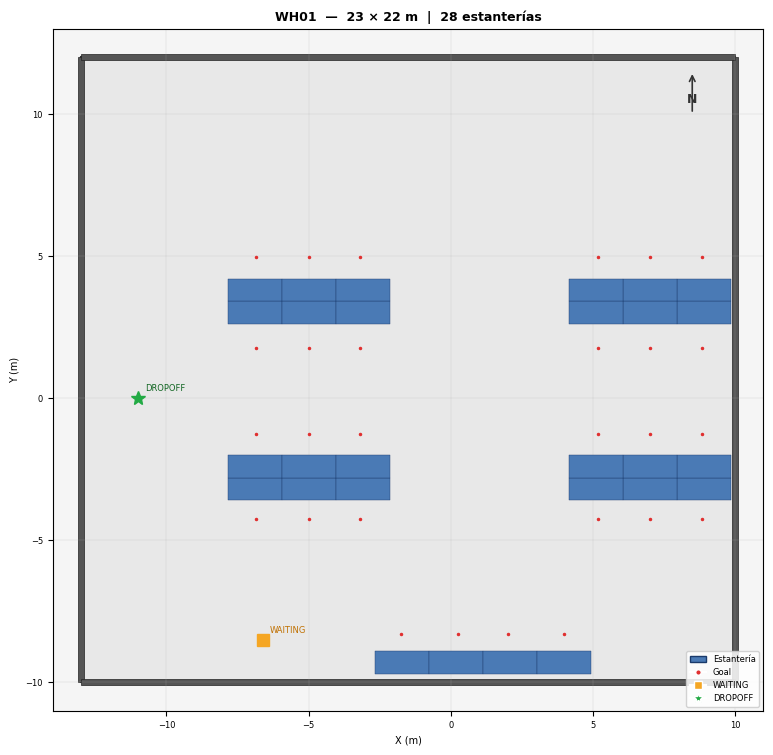

  → imagenes/warehouse_01.png


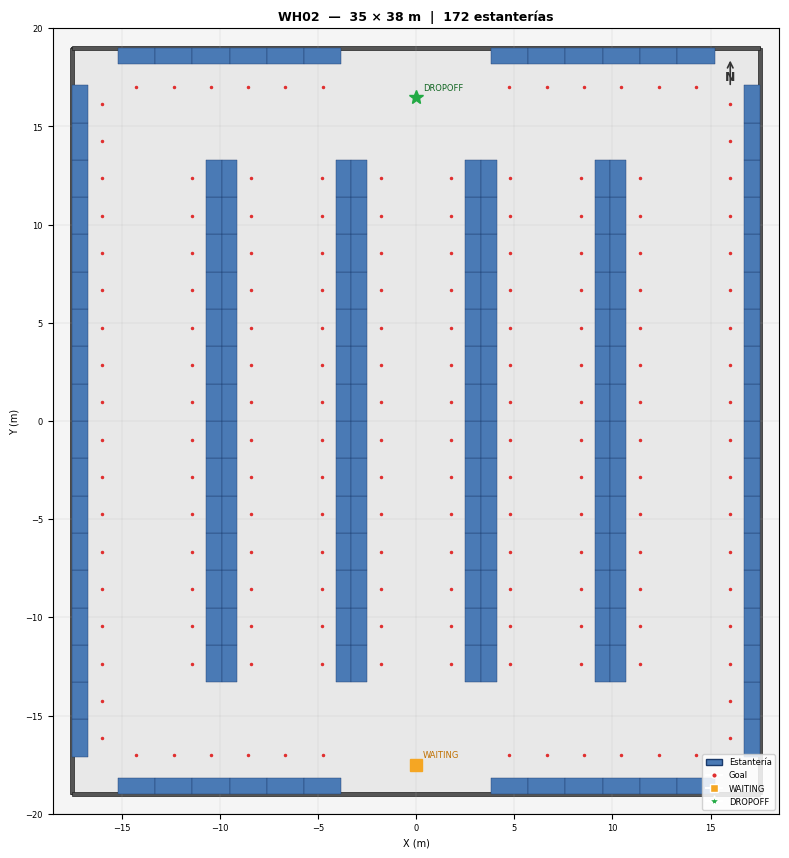

  → imagenes/warehouse_02.png


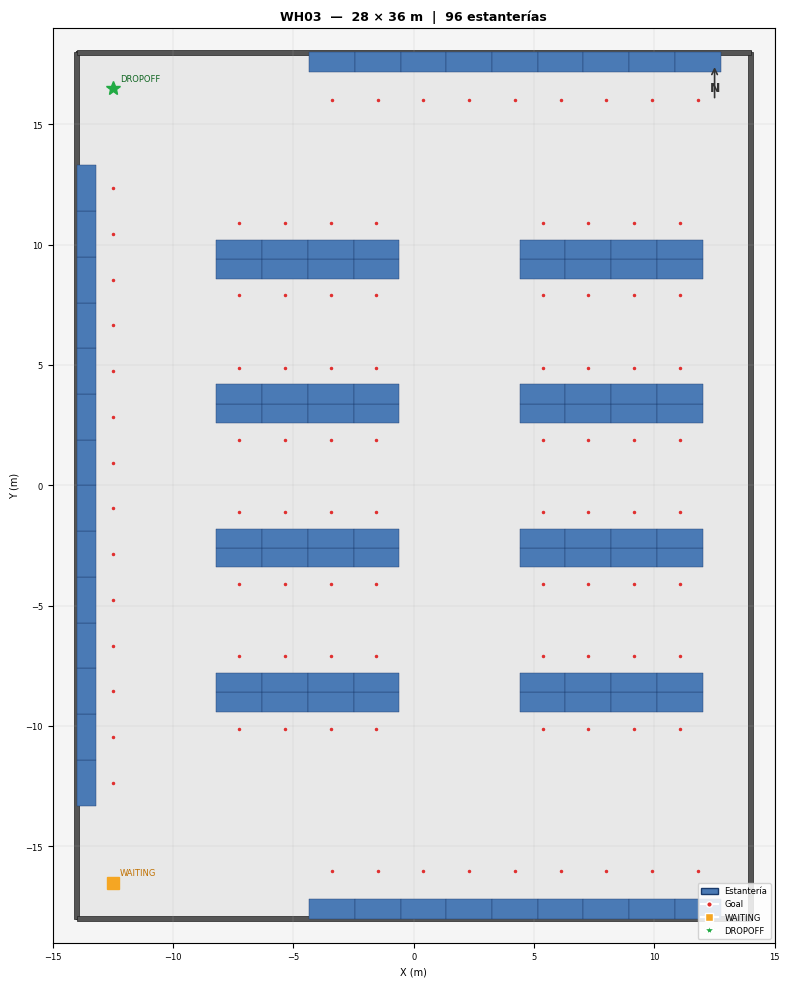

  → imagenes/warehouse_03.png


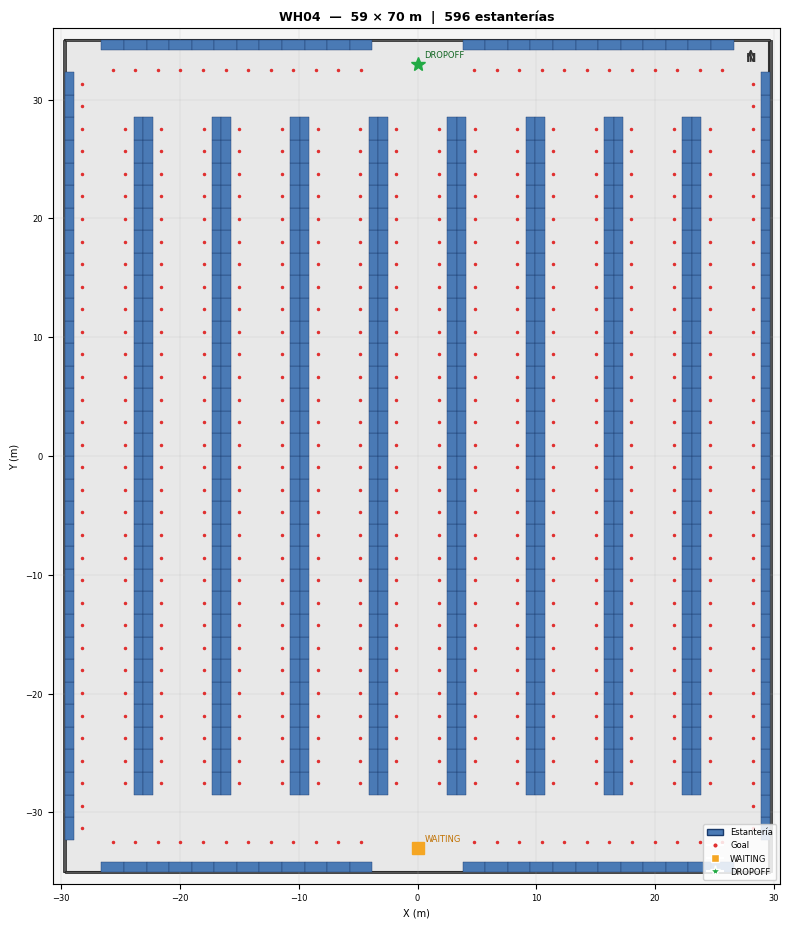

  → imagenes/warehouse_04.png


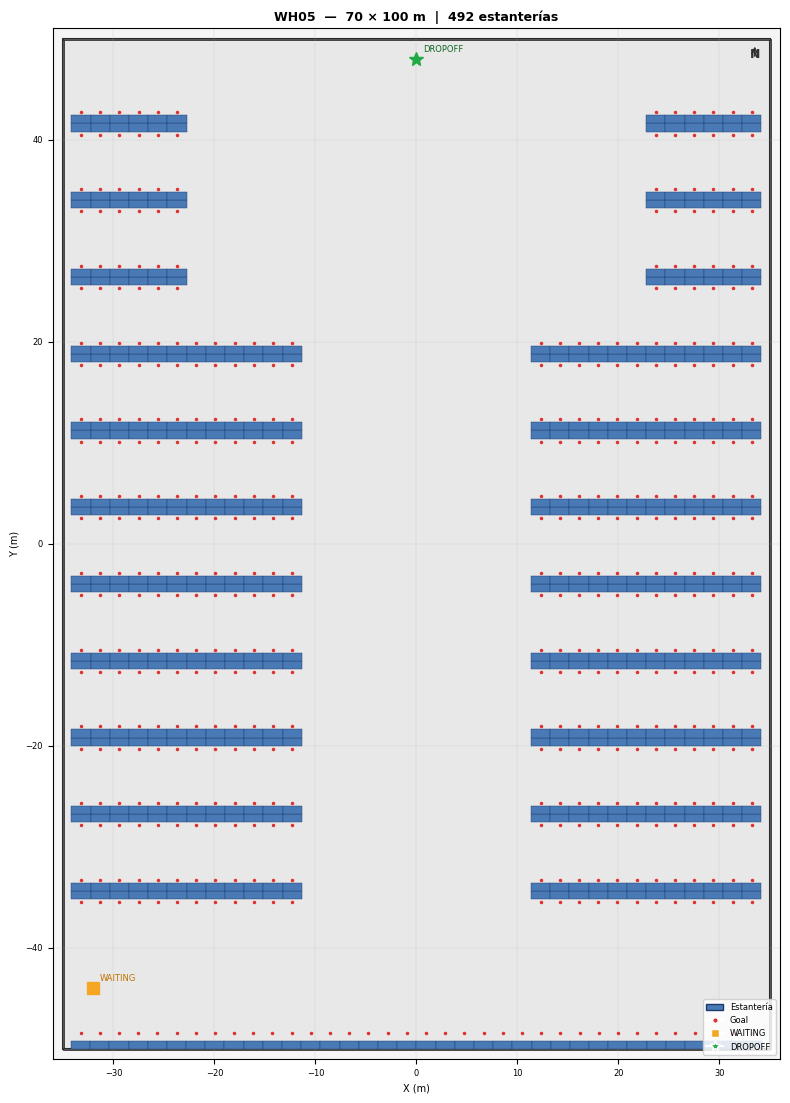

  → imagenes/warehouse_05.png


In [3]:
SHELF_L = 1.9   # longitud en la dimensión larga
SHELF_W = 0.8   # profundidad
SHELF_H = 1.8

def shelf_rect(sx, sy, rot90=False):
    """Devuelve (x_bl, y_bl, width, height) del rectángulo de la estantería."""
    if rot90:
        w, h = SHELF_L, SHELF_W
    else:
        w, h = SHELF_W, SHELF_L
    return sx - w / 2, sy - h / 2, w, h

def guess_rot90(d):
    """
    Infiere si una estantería está rotada 90° comparando la diferencia
    entre su posición Y y la del goal (si la diferencia es mayor en Y
    que en X, la estantería corre en X → rot90).
    """
    sx, sy = d['shelf_x'], d['shelf_y']
    gx, gy = d['goal_x'],  d['goal_y']
    dy = abs(gy - sy)
    dx = abs(gx - sx)
    # si el goal está desplazado en Y y no en X → rot90
    return dy > dx

def plot_warehouse(wh_id, data, ax):
    m      = data['map']
    res    = m['resolution']
    W      = m['width']  * res
    L      = m['height'] * res
    ox, oy = m['origin']
    xmin, xmax = ox, ox + W
    ymin, ymax = oy, oy + L

    shelves = data['shelves']
    zones   = data['zones']
    walls   = data.get('walls', [])

    ax.set_facecolor('#f5f5f5')
    ax.set_aspect('equal')
    ax.set_xlim(xmin - 1, xmax + 1)
    ax.set_ylim(ymin - 1, ymax + 1)

    # Suelo
    floor = mpatches.Rectangle((xmin, ymin), W, L,
                                linewidth=1.5, edgecolor='#333',
                                facecolor='#e8e8e8', zorder=0)
    ax.add_patch(floor)

    # Paredes (si las hay con geometría explícita)
    for wall in walls:
        wx, wy = wall['x'], wall['y']
        ww, wh = wall['w'], wall['h']
        wr = mpatches.Rectangle((wx - ww/2, wy - wh/2), ww, wh,
                                 facecolor='#555', edgecolor='#222',
                                 linewidth=0.5, zorder=1)
        ax.add_patch(wr)

    # Estanterías y goals
    for s in shelves:
        rot = guess_rot90(s)
        rx, ry, rw, rh = shelf_rect(s['shelf_x'], s['shelf_y'], rot)
        rect = mpatches.Rectangle((rx, ry), rw, rh,
                                   facecolor='#4a7ab5', edgecolor='#1a3a6b',
                                   linewidth=0.3, zorder=2)
        ax.add_patch(rect)
        # Goal (punto pequeño rojo)
        ax.plot(s['goal_x'], s['goal_y'], 'o',
                color='#e03030', markersize=1.5, zorder=3)

    # WAITING
    wx_w, wy_w = zones['waiting']['x'], zones['waiting']['y']
    ax.plot(wx_w, wy_w, 's', color='#f5a623', markersize=8, zorder=5,
            label='WAITING')
    ax.annotate('WAITING', (wx_w, wy_w),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6, color='#c07000')

    # DROPOFF
    dx_d, dy_d = zones['dropoff']['x'], zones['dropoff']['y']
    ax.plot(dx_d, dy_d, '*', color='#22aa44', markersize=10, zorder=5,
            label='DROPOFF')
    ax.annotate('DROPOFF', (dx_d, dy_d),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6, color='#116622')

    # Indicador Norte
    ax.annotate('N', xy=(xmax - 1.5, ymax - 1.5), fontsize=9,
                fontweight='bold', ha='center', va='center',
                color='#333')
    ax.annotate('', xy=(xmax - 1.5, ymax - 0.5),
                xytext=(xmax - 1.5, ymax - 2.0),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))

    ax.set_title(f'WH{wh_id:02d}  —  {W:.0f} × {L:.0f} m  |  {len(shelves)} estanterías',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, linewidth=0.3, alpha=0.5)

    legend_elements = [
        mpatches.Patch(facecolor='#4a7ab5', edgecolor='#1a3a6b', label='Estantería'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#e03030',
                   markersize=4, label='Goal'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#f5a623',
                   markersize=6, label='WAITING'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#22aa44',
                   markersize=8, label='DROPOFF'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=6,
              framealpha=0.85)

# ── Figura individual por almacén ──────────────────────────────────────────────
for wh_id, data in maps.items():
    m   = data['map']
    res = m['resolution']
    W   = m['width']  * res
    L   = m['height'] * res
    aspect = L / W
    fig_w = 8
    fig_h = max(5, min(14, fig_w * aspect))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    plot_warehouse(wh_id, data, ax)
    plt.tight_layout()
    out_path = OUT_DIR / f'warehouse_{wh_id:02d}.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → {out_path}')

## Vista conjunta (todos los almacenes)

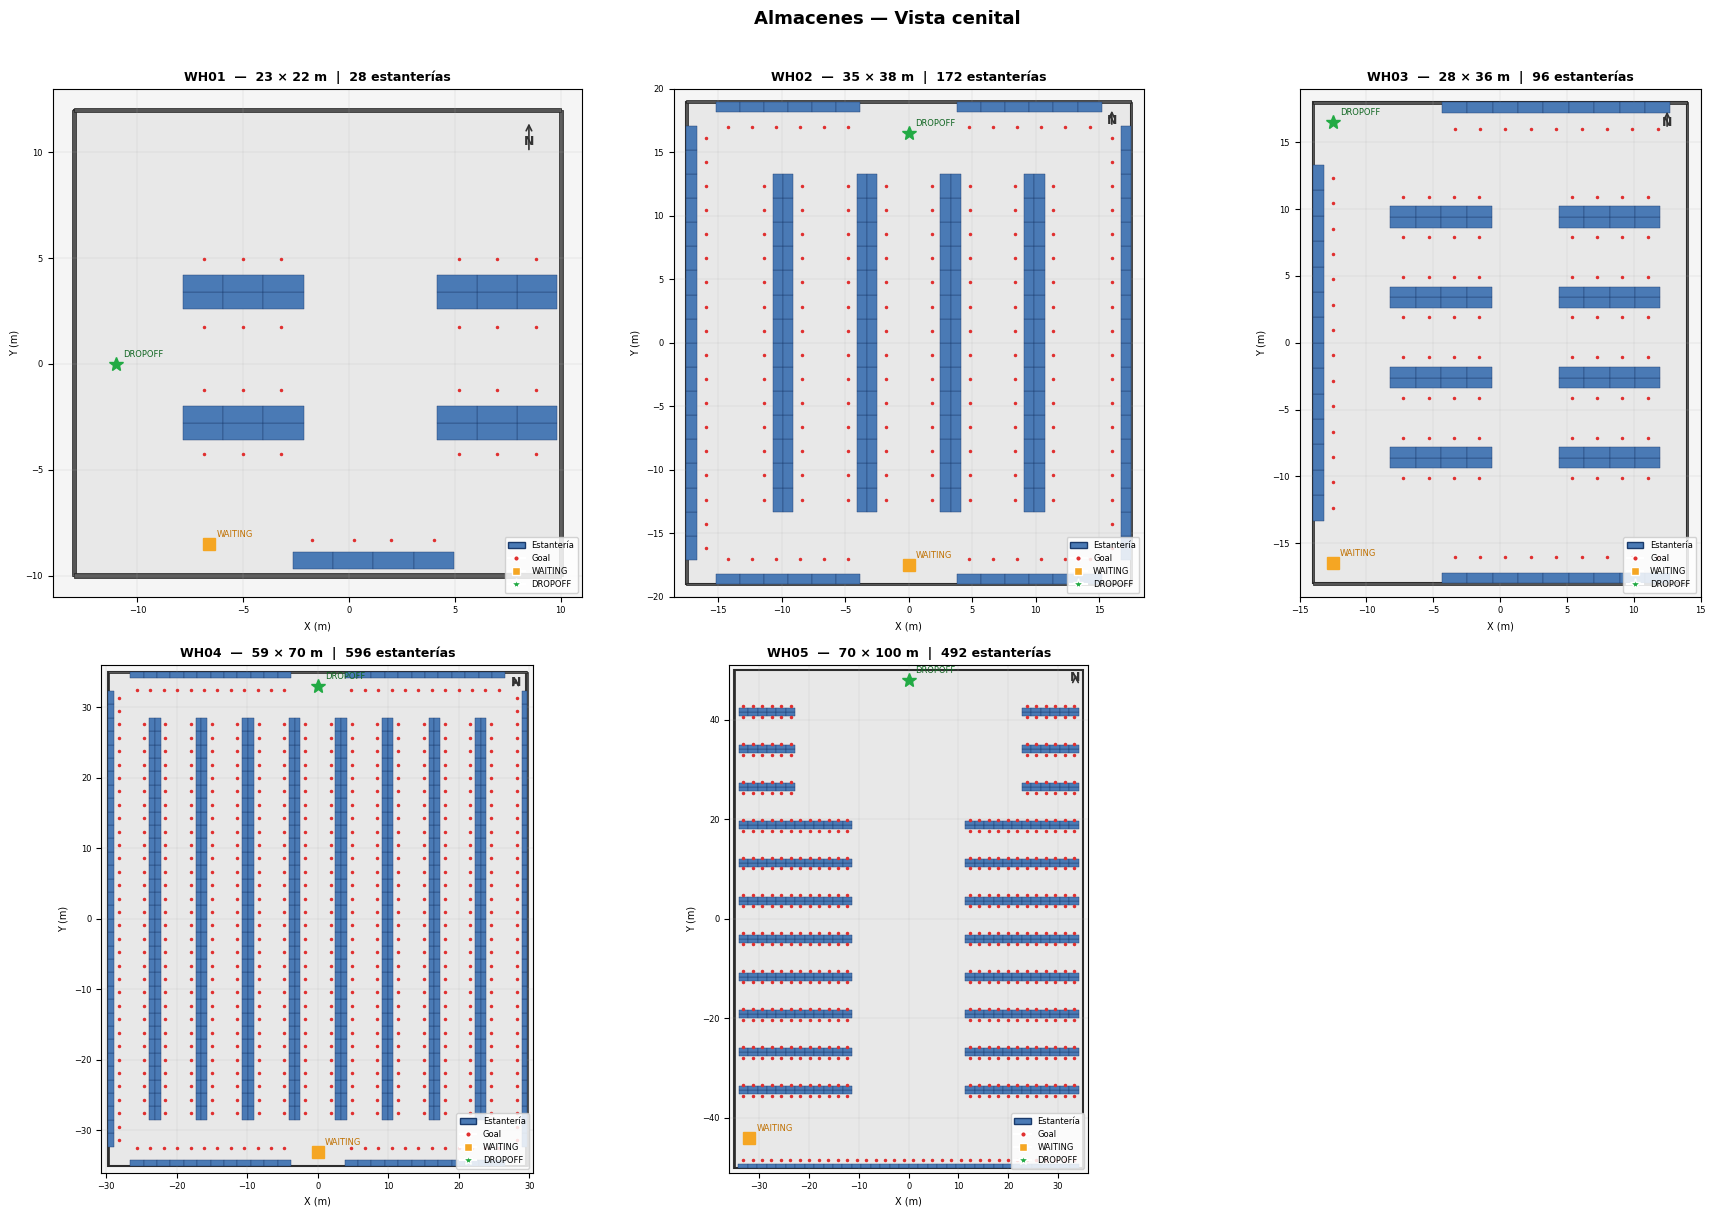

  → imagenes/todos_los_almacenes.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (wh_id, data) in enumerate(maps.items()):
    plot_warehouse(wh_id, data, axes[idx])

# Ocultar subplot sobrante
for ax in axes[len(maps):]:
    ax.set_visible(False)

plt.suptitle('Almacenes — Vista cenital', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = OUT_DIR / 'todos_los_almacenes.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  → {out_path}')